In [ ]:
# core
import os
import numpy as np
import pandas as pd

# modeling
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_predict, cross_val_score

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# utils
from math import sqrt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# path to your training data
data_path = "./data/train_real.csv"  # change if needed
df = pd.read_csv(data_path)

# columns to exclude from features (same as RF script)
non_feature_cols = {
    "mxene","gibbs_free_energy","composition_obj"
}

# feature columns = all except the excluded ones (then keep only numeric)
feature_cols = [c for c in df.columns if c not in non_feature_cols]
X_all = df[feature_cols].select_dtypes(include=[np.number]).copy()

# label (same target as RF version)
target_col = "gibbs_free_energy"
y_all = df[target_col].astype(float).copy()

# basic checks
print("n_samples:", len(df))
print("n_features (numeric):", X_all.shape[1])
print("first 5 feature columns:", feature_cols[:5])
X_all.head()


n_samples: 538
n_features (numeric): 250
first 5 feature columns: ['H', 'He', 'Li', 'Be', 'B']


,H,He,Li,Be,B,C,N,O,F,Ne,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.4,0.0,...,0.0,0.0,0.0,0.0,15.0,229.0,214.0,130.8,92.64,15.0
1,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.4,0.0,...,0.0,0.0,0.0,0.0,15.0,229.0,214.0,129.4,91.52,15.0
2,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.4,0.0,...,0.0,0.0,0.0,0.0,15.0,229.0,214.0,136.4,97.12,15.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,64.0,229.0,165.0,156.0,73.60,64.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.4,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,229.0,217.0,135.2,98.56,12.0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# simple imputation (median) to handle any missing values
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))  # use train medians

print("train shape:", X_train.shape, "| test shape:", X_test.shape)


train shape: (430, 250) | test shape: (108, 250)


In [4]:
# choose fast/robust tree method
# "hist" is fast on CPU; switch to "gpu_hist" if you know a CUDA GPU is available
TREE_METHOD = "hist"

xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    n_estimators=500,          # will be overridden by grid when applicable
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=1.0,
    objective="reg:squarederror",
    n_jobs=1,
    tree_method=TREE_METHOD,
)

# a compact but effective grid; adjust as needed
param_grid = {
    "n_estimators": [400, 800],
    "max_depth": [6, 10],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "min_child_weight": [1, 3],
    "reg_lambda": [1.0, 5.0],
    "reg_alpha": [0.0, 0.5],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gscv = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gscv.fit(X_train, y_train)
best_xgb = gscv.best_estimator_
print("best params:", gscv.best_params_)
print("best cv RMSE:", -gscv.best_score_)


Fitting 5 folds for each of 256 candidates, totalling 1280 fits
best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 400, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.8}
best cv RMSE: 0.599770462776516


In [5]:
def eval_regression(y_true, y_pred, label=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} RMSE: {rmse:.3f} | MAE: {mae:.3f} | R2: {r2:.3f}")
    return rmse, mae, r2

# predictions
yhat_tr = best_xgb.predict(X_train)
yhat_te = best_xgb.predict(X_test)

print("== training ==")
tr_metrics = eval_regression(y_train, yhat_tr, "train")

print("\n== test ==")
te_metrics = eval_regression(y_test, yhat_te, "test")

# cross-validated metrics across the full dataset (same as RF style)
try:
    cv_rmse = -cross_val_score(best_xgb, X_all, y_all, cv=cv,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
except ValueError:
    mse_scores = -cross_val_score(best_xgb, X_all, y_all, cv=cv,
                                  scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rmse = np.sqrt(mse_scores)

cv_mae  = -cross_val_score(best_xgb, X_all, y_all, cv=cv,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
cv_r2   =  cross_val_score(best_xgb, X_all, y_all, cv=cv, scoring="r2", n_jobs=-1)

print(f"\ncv RMSE: mean={cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"cv MAE : mean={cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"cv R2  : mean={cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# CV predictions for parity plot
yhat_cv = cross_val_predict(best_xgb, X_all, y_all, cv=cv, n_jobs=-1)


== training ==
train RMSE: 0.100 | MAE: 0.016 | R2: 0.993

== test ==
test RMSE: 0.802 | MAE: 0.493 | R2: 0.524

cv RMSE: mean=0.705 ± 0.096
cv MAE : mean=0.433 ± 0.053
cv R2  : mean=0.628 ± 0.084


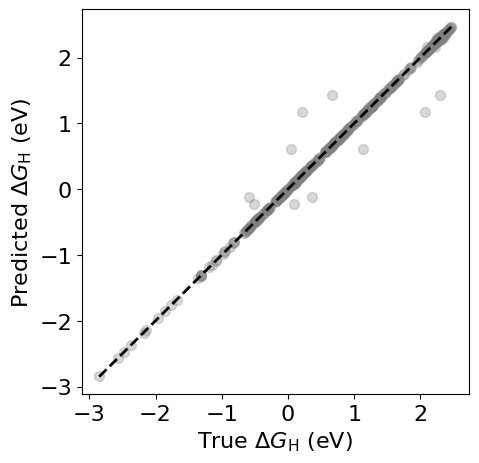

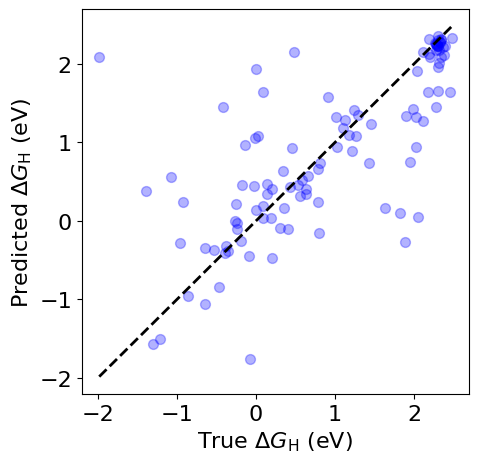

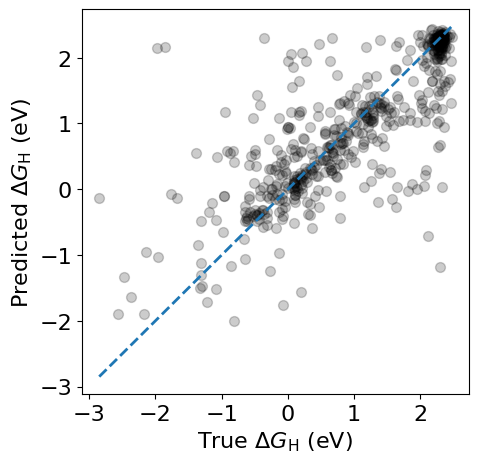

In [8]:
# --- Train parity ---
plt.figure(figsize=(5,5))
plt.scatter(y_train, yhat_tr, s=50, alpha=0.3, c="grey")
lims = [min(y_train.min(), yhat_tr.min()), max(y_train.max(), yhat_tr.max())]
plt.plot(lims, lims, linewidth=2, color="black", linestyle="--")
plt.xlabel(r"True $\Delta G_\mathrm{H}$ (eV)", fontsize=16)
plt.ylabel(r"Predicted $\Delta G_\mathrm{H}$ (eV)", fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
os.makedirs("./visual", exist_ok=True)
plt.savefig('./visual/fig_s3e.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()

# --- Test parity ---
plt.figure(figsize=(5,5))
plt.scatter(y_test, yhat_te, s=50, alpha=0.3, c="blue")
lims = [min(y_test.min(), yhat_te.min()), max(y_test.max(), yhat_te.max())]
plt.plot(lims, lims, linewidth=2, color="black", linestyle="--")
plt.xlabel(r"True $\Delta G_\mathrm{H}$ (eV)", fontsize=16)
plt.ylabel(r"Predicted $\Delta G_\mathrm{H}$ (eV)", fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.savefig('./visual/fig4c.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()

# --- Cross-validation parity ---
plt.figure(figsize=(5,5))
plt.scatter(y_all, yhat_cv, s=50, alpha=0.2, c="black")
lims = [min(y_all.min(), yhat_cv.min()), max(y_all.max(), yhat_cv.max())]
plt.plot(lims, lims, linewidth=2, color="tab:blue", linestyle="--")
plt.xlabel(r"True $\Delta G_\mathrm{H}$ (eV)", fontsize=16)
plt.ylabel(r"Predicted $\Delta G_\mathrm{H}$ (eV)", fontsize=16)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.savefig('./visual/fig_s3f.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


/tmp/ipykernel_226344/126522334.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_top_short.values, y=imp_top_short.index, palette="viridis")


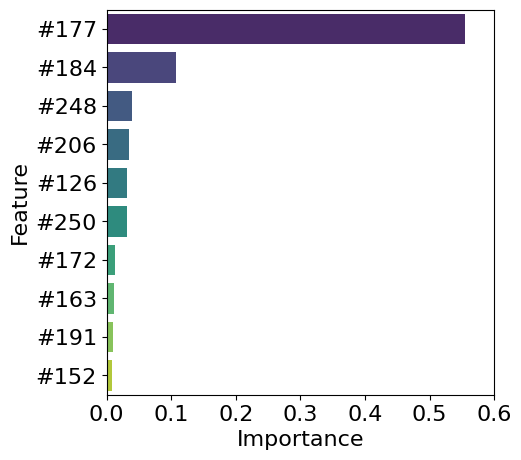

,Short name
MagpieData avg_dev NpValence,#177
MagpieData mode NdValence,#184
MagpieData mean SpaceGroupNumber,#248
MagpieData mean NpUnfilled,#206
MagpieData maximum MendeleevNumber,#126
MagpieData mode SpaceGroupNumber,#250
MagpieData mode NsValence,#172
MagpieData range Electronegativity,#163
MagpieData minimum NValence,#191
MagpieData mean Row,#152


In [7]:
# XGBoost exposes feature_importances_ (by default = 'gain' in sklearn API)
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)

# get top 10
imp_top = importances.sort_values(ascending=False).head(10)

# map original feature names → Feature #XXX (keep same style as RF)
feature_map = {
    feat: f"#{str(X_train.columns.get_loc(feat)+1).zfill(3)}"
    for feat in imp_top.index
}
imp_top_short = imp_top.rename(index=feature_map)

plt.figure(figsize=(5,5))
sns.barplot(x=imp_top_short.values, y=imp_top_short.index, palette="viridis")
plt.xlabel("Importance", fontsize=16)
plt.ylabel("Feature", fontsize=16)

# set xticks at 0.00, 0.05, 0.10, ...
max_val = float(imp_top_short.max())
tick_step = 0.1 if max_val > 0.05 else max(0.01, round(max_val/4, 3))
ticks = np.arange(0, max_val + tick_step, tick_step)
plt.xticks(ticks, fontsize=16)
plt.yticks(fontsize=16)

plt.savefig('./visual/fig4d.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()

# lookup table for reference
lookup = pd.DataFrame.from_dict(feature_map, orient="index", columns=["Short name"])
display(lookup)


In [ ]:
# # path to your new feature-only csv
# new_features_path = "/mnt/data/new_features.csv"   # change to your file
# out_path = "/mnt/data/predictions_xgb.csv"         # where to save

# new_df = pd.read_csv(new_features_path)

# # ensure same columns & order as training
# missing = set(X_train.columns) - set(new_df.columns)
# extra   = set(new_df.columns) - set(X_train.columns)

# if missing:
#     raise ValueError(f"the following required feature columns are missing in the input: {sorted(missing)[:10]} ...")

# X_new = new_df.reindex(columns=X_train.columns, fill_value=np.nan)
# X_new = X_new.fillna(X_train.median(numeric_only=True))

# # predict
# pred = best_xgb.predict(X_new)

# # write out
# pred_df = new_df.copy()
# pred_df["predicted_formation_energy_per_atom"] = pred
# pred_df.to_csv(out_path, index=False)
# print(f"saved predictions to: {out_path}")
# pred_df.head()
